#  Ford GoBike Data Analysis Project

##  Project Overview 
This project aims to analyze the Ford GoBike system dataset to understand rider behavior, demographic patterns, and trip durations. The dataset contains trip data collected in 2019.

##  Objectives 
1. **Data Assessment :** Explore the dataset to find structural issues, missing values, and anomalies.
2. **Data Cleaning :** Handle outliers, drop unnecessary columns, and engineer new features.
3. **Exporting:** Save the high-quality, cleaned dataset for the Data Visualization phase.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read the data
data = pd.read_csv(r'D:\AI\ai_deploma_master\ai_deploma_master\Data_Analysis\Final_Project\FordGoBike_Project-main\data\fordgobike_cleaned.csv')


##  Phase 1: Data Assessment  
In this section, we will load the dataset and perform an initial inspection to understand its structure, dimensions, and data types. We will also check for missing values (NaN) and duplicated rows.

In [3]:
# shape of the data
Data_shape=data.shape
print(Data_shape)
print('------------------------')
# head data
data.head()

(174952, 16)
------------------------


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984,Male,No
1,61854,13:13.2,24:08.1,86,Market St at Dolores St,37.769305,-122.426826,3,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972,Male,No
2,36490,54:26.0,02:36.8,375,Grove St at Masonic Ave,37.774836,-122.446546,70,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989,Other,No
3,1585,54:18.5,20:44.1,7,Frank H Ogawa Plaza,37.804562,-122.271738,222,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974,Male,Yes
4,1793,49:58.6,19:51.8,93,4th St at Mission Bay Blvd S,37.770407,-122.391198,323,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959,Male,No


In [4]:
# info of the data
data.info()
print('------------------------')
# decribtion of the data
data.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174952 entries, 0 to 174951
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             174952 non-null  int64  
 1   start_time               174952 non-null  object 
 2   end_time                 174952 non-null  object 
 3   start_station_id         174952 non-null  int64  
 4   start_station_name       174952 non-null  object 
 5   start_station_latitude   174952 non-null  float64
 6   start_station_longitude  174952 non-null  float64
 7   end_station_id           174952 non-null  int64  
 8   end_station_name         174952 non-null  object 
 9   end_station_latitude     174952 non-null  float64
 10  end_station_longitude    174952 non-null  float64
 11  bike_id                  174952 non-null  int64  
 12  user_type                174952 non-null  object 
 13  member_birth_year        174952 non-null  int64  
 14  memb

,count,mean,std,min,25%,50%,75%,max
duration_sec,174952.0,704.002744,1642.204905,61.000000,323.000000,510.000000,789.000000,84548.000000
start_station_id,174952.0,139.002126,111.648819,3.000000,47.000000,104.000000,239.000000,398.000000
start_station_latitude,174952.0,37.771220,0.100391,37.317298,37.770407,37.780760,37.797320,37.880222
start_station_longitude,174952.0,-122.351760,0.117732,-122.453705,-122.411901,-122.398279,-122.283093,-121.874119
end_station_id,174952.0,136.604486,111.335635,3.000000,44.000000,101.000000,238.000000,398.000000
end_station_latitude,174952.0,37.771414,0.100295,37.317298,37.770407,37.781010,37.797673,37.880222
end_station_longitude,174952.0,-122.351335,0.117294,-122.453705,-122.411647,-122.397437,-122.286533,-121.874119
bike_id,174952.0,4482.587555,1659.195937,11.000000,3799.000000,4960.000000,5505.000000,6645.000000
member_birth_year,174952.0,1984.803135,10.118731,1878.000000,1980.000000,1987.000000,1992.000000,2001.000000


In [5]:
# check if there is any null values
data.isnull().sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

In [6]:
# check duplicated values
data.duplicated().sum()

np.int64(0)

In [7]:
# unique values of the data
data.nunique()

duration_sec                4429
start_time                 35732
end_time                   35717
start_station_id             329
start_station_name           329
start_station_latitude       329
start_station_longitude      329
end_station_id               329
end_station_name             329
end_station_latitude         329
end_station_longitude        329
bike_id                     4607
user_type                      2
member_birth_year             75
member_gender                  3
bike_share_for_all_trip        2
dtype: int64

In [8]:
# check the row number with null values
data[data.isnull().any(axis=1)] 

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip


**Cleaning data**

##  Phase 2: Data Cleaning 
Based on the assessment phase, we will perform the following cleaning steps:
1. **Remove Duplicates:** Ensure there are no identical rows.
2. **Handle Outliers :** - Use the **IQR (Interquartile Range)** method to detect and filter out unrealistic trip durations (e.g., trips > 2 hours).
   - Filter out impossible birth years (e.g., birth years before 1940).
3. **Feature Engineering :** - Convert `member_birth_year` to a more useful `age` column (assuming the current year of data collection is 2019).
   - Convert `duration_sec` to `duration_min` for better readability.
4. **Drop Unnecessary Columns:** Remove geospatial data (Lat/Long), IDs, and corrupted time columns (`start_time`, `end_time`) to optimize memory and focus the analysis.

In [9]:
# drop_duplicates value
data.drop_duplicates(inplace=True)


In [10]:
# outlier


def calculate_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    
    return outliers, lower_bound, upper_bound

# ---------------------------------------------------------
duration_outliers, duration_lower, duration_upper = calculate_outliers_iqr(data['duration_sec'])
duration_outliers_percentage = (len(duration_outliers) / len(data)) * 100

print("--- Outliers in 'duration_sec' ---")
print(f"Total Outliers: {len(duration_outliers)} ({duration_outliers_percentage:.2f}%)")
print(f"Lower Bound: {duration_lower}")
print(f"Upper Bound: {duration_upper}")
print(f"Max duration value: {data['duration_sec'].max()}\n")

# ---------------------------------------------------------
birth_outliers, birth_lower, birth_upper = calculate_outliers_iqr(data['member_birth_year'])
birth_outliers_percentage = (len(birth_outliers) / len(data)) * 100

print("--- Outliers in 'member_birth_year' ---")
print(f"Total Outliers: {len(birth_outliers)} ({birth_outliers_percentage:.2f}%)")
print(f"Lower Bound: {birth_lower}")
print(f"Upper Bound: {birth_upper}")
print(f"Oldest birth year (Min value): {data['member_birth_year'].min()}\n")

# ---------------------------------------------------------
data = data[
    (data['member_birth_year'] >= 1940) &  
    (data['duration_sec'] <= 7200)        ]

print(f"Data shape after cleaning outliers: {data.shape}")


--- Outliers in 'duration_sec' ---
Total Outliers: 9328 (5.33%)
Lower Bound: -376.0
Upper Bound: 1488.0
Max duration value: 84548

--- Outliers in 'member_birth_year' ---
Total Outliers: 5781 (3.30%)
Lower Bound: 1962.0
Upper Bound: 2010.0
Oldest birth year (Min value): 1878

Data shape after cleaning outliers: (174211, 16)


In [11]:
# 1. Feature Engineering: Calculate Age
# The data was collected in 2019, so Age = 2019 - Birth Year
data['member_birth_year'] = 2019 - data['member_birth_year']
data.rename(columns={'member_birth_year': 'age'}, inplace=True)

# 2. Convert trip duration from seconds to minutes for better readability
data['duration_sec'] = data['duration_sec'] / 60
data.rename(columns={'duration_sec': 'duration_min'}, inplace=True) # Renaming the column appropriately

In [12]:
# 3. Drop unuseful and redundant columns to optimize memory
# Note: start_time and end_time are dropped because they suffered from data extraction corruption (missing date/hours)
columns_to_drop = [
    'start_station_latitude', 
    'start_station_longitude', 
    'end_station_latitude', 
    'end_station_longitude',
    'bike_id',
    'start_station_id',
    'end_station_id',
    'start_time',  # Added this based on our discussion
    'end_time'
]

data.drop(columns_to_drop, axis=1, inplace=True)

# 4. Convert specific columns to 'category' data type to save memory (Optional but Recommended)
cols_to_category = ['user_type', 'member_gender', 'bike_share_for_all_trip']
for col in cols_to_category:
    data[col] = data[col].astype('category')


##  Phase 2.5: Optimize Memory Usage (Handling Categorical Data)
To optimize the DataFrame's memory footprint and speed up future analysis, we will convert features that have a limited set of distinct values (like gender and user type) from `object` (strings) to the `category` data type.

In [13]:

# 1. Check memory usage before conversion (for demonstration)
mem_before = data.memory_usage(deep=True).sum() / (1024 ** 2) # Convert to Megabytes
print(f"Memory usage BEFORE converting to Category: {mem_before:.2f} MB")

# 2. Define the columns that should be categorical
cols_to_category = ['user_type', 'member_gender', 'bike_share_for_all_trip']

# 3. Convert them using a loop
for col in cols_to_category:
    data[col] = data[col].astype('category')

# 4. Check memory usage after conversion
mem_after = data.memory_usage(deep=True).sum() / (1024 ** 2)
reduction = ((mem_before - mem_after) / mem_before) * 100

print(f"Memory usage AFTER converting to Category: {mem_after:.2f} MB")
print(f"Total memory saved: {reduction:.2f}%")

# 5. Verify the new data types
print("\n--- Current Data Types ---")
print(data.dtypes)

Memory usage BEFORE converting to Category: 29.59 MB
Memory usage AFTER converting to Category: 29.59 MB
Total memory saved: 0.00%

--- Current Data Types ---
duration_min                float64
start_station_name           object
end_station_name             object
user_type                  category
age                           int64
member_gender              category
bike_share_for_all_trip    category
dtype: object


##  Phase 2.7: Handling High-Cardinality Categorical Data
The dataset contains 329 unique start and end stations. Plotting all of them on a single chart would be visually overwhelming and uninformative. 
To prepare for the visualization phase, we will filter the dataset to extract only the **Top 10 most popular start and end stations**. This allows us to create clean, readable bar charts that highlight the highest-traffic hubs in the Ford GoBike network.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert low-cardinality columns to 'category' data type
cols_to_category = ['member_gender', 'bike_share_for_all_trip']
for col in cols_to_category:
    data[col] = data[col].astype('category')

# 2. Prepare high-cardinality station data (Extracting Top 10 only)
# Get the names of the top 10 most popular start stations
top_10_start_stations = data['start_station_name'].value_counts().nlargest(10).index

# Get the names of the top 10 most popular end stations
top_10_end_stations = data['end_station_name'].value_counts().nlargest(10).index

# Filter: Create new DataFrames containing ONLY trips from/to these top 10 stations
df_top_start = data[data['start_station_name'].isin(top_10_start_stations)]
df_top_end = data[data['end_station_name'].isin(top_10_end_stations)]

print("Top 10 Start & End Stations successfully extracted and ready for visualization!")

Top 10 Start & End Stations successfully extracted and ready for visualization!


## Phase 4: Save Cleaned Data
Now that the data is clean, memory-optimized, and focused on the relevant features, we will export it to a new CSV file. This file will be the primary source for the Data Visualization and Dashboarding phase.

In [15]:
# save the cleaned data to a new csv file
data.to_csv(r'D:\AI\ai_deploma_master\ai_deploma_master\Data_Analysis\Final_Project\FordGoBike_Project-main\data\fordgobike-tripdataFor201902_cleaned.csv', index=False)    

In [16]:
data

,duration_min,start_station_name,end_station_name,user_type,age,member_gender,bike_share_for_all_trip
3,26.416667,Frank H Ogawa Plaza,10th Ave at E 15th St,Subscriber,45,Male,Yes
4,29.883333,4th St at Mission Bay Blvd S,Broadway at Kearny,Subscriber,60,Male,No
5,19.116667,Palm St at Willow St,San Jose Diridon Station,Subscriber,36,Female,No
6,26.916667,Washington St at Kearny St,Valencia St at 21st St,Subscriber,30,Male,No
7,26.166667,Washington St at Kearny St,Valencia St at 21st St,Subscriber,31,Other,No
...,...,...,...,...,...,...,...
174947,8.000000,Beale St at Harrison St,Union Square (Powell St at Post St),Subscriber,23,Male,No
174948,5.216667,Montgomery St BART Station (Market St at 2nd St),3rd St at Townsend St,Subscriber,35,Male,No
174949,2.350000,The Alameda at Bush St,Morrison Ave at Julian St,Subscriber,29,Male,Yes
174950,2.316667,San Pablo Ave at MLK Jr Way,San Pablo Ave at 27th St,Subscriber,31,Male,No


## Phase 4: Exploratory Data Analysis (EDA)
### 3.1 Univariate Analysis
In this section, we will investigate the distributions of individual variables of interest.
**Main questions to answer:**
- What is the proportion of Subscribers vs. Customers?
- What is the gender distribution of the riders?
- What are the most popular starting and ending stations?
- How are trip durations and user ages distributed?

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style and default color for all plots
sns.set_style('whitegrid')
base_color = sns.color_palette()[0] # Standard uniform color for simple bar charts

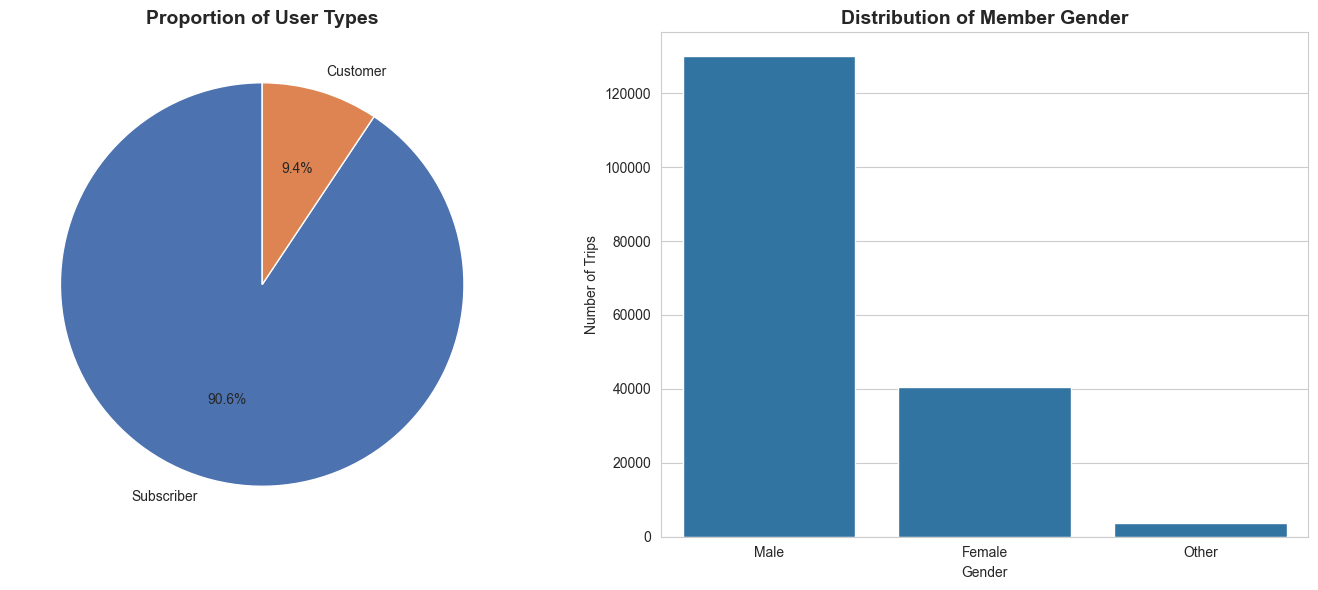

In [18]:
# Create a figure with two subplots (1 row, 2 columns)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# 1. User Type Distribution
user_type_counts = data['user_type'].value_counts()
ax[0].pie(user_type_counts, labels=user_type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#DD8452'])
ax[0].set_title('Proportion of User Types', fontsize=14, fontweight='bold')

# 2. Member Gender Distribution
sns.countplot(data=data, x='member_gender', color=base_color, ax=ax[1], order=data['member_gender'].value_counts().index)
ax[1].set_title('Distribution of Member Gender', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Gender')
ax[1].set_ylabel('Number of Trips')

plt.tight_layout()
plt.show()

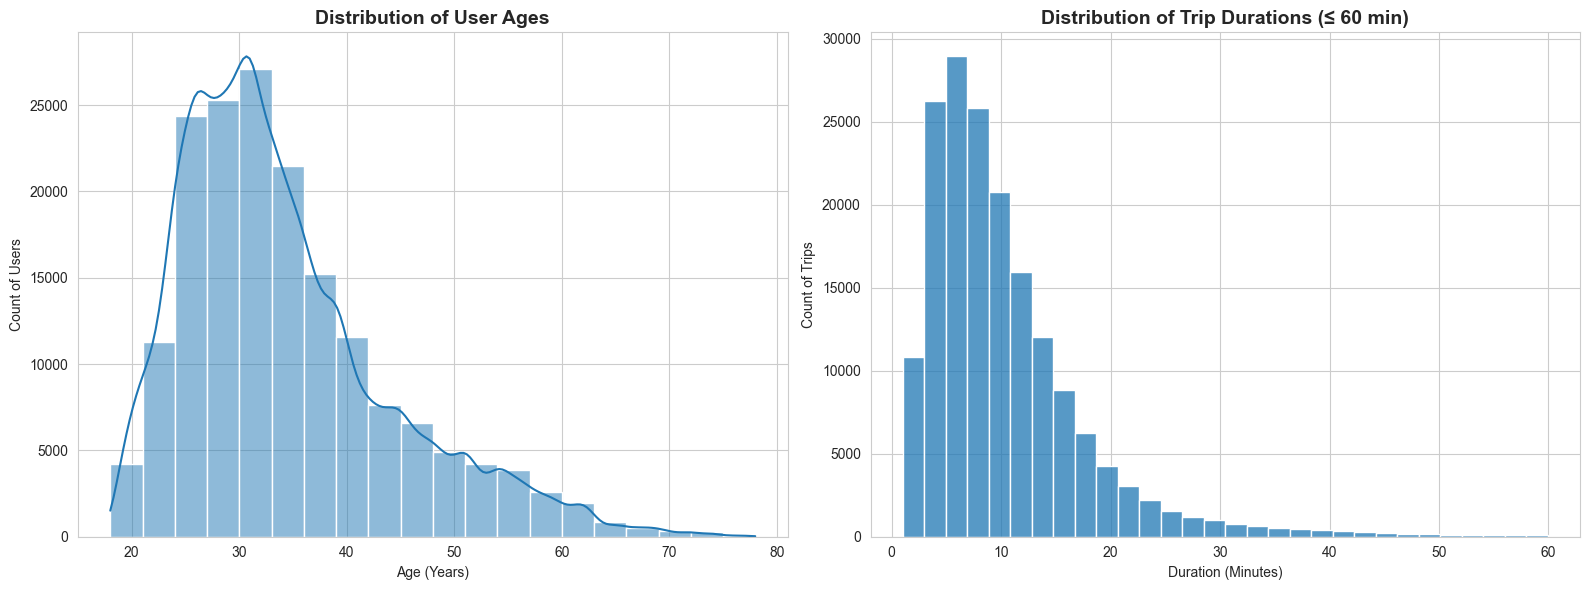

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# 1. Age Distribution
sns.histplot(data=data, x='age', bins=20, color=base_color, kde=True, ax=ax[0])
ax[0].set_title('Distribution of User Ages', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Age (Years)')
ax[0].set_ylabel('Count of Users')

# 2. Trip Duration Distribution (focused on trips under 60 minutes for better visibility)
sns.histplot(data=data[data['duration_min'] <= 60], x='duration_min', bins=30, color=base_color, ax=ax[1])
ax[1].set_title('Distribution of Trip Durations (≤ 60 min)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Duration (Minutes)')
ax[1].set_ylabel('Count of Trips')

plt.tight_layout()
plt.show()

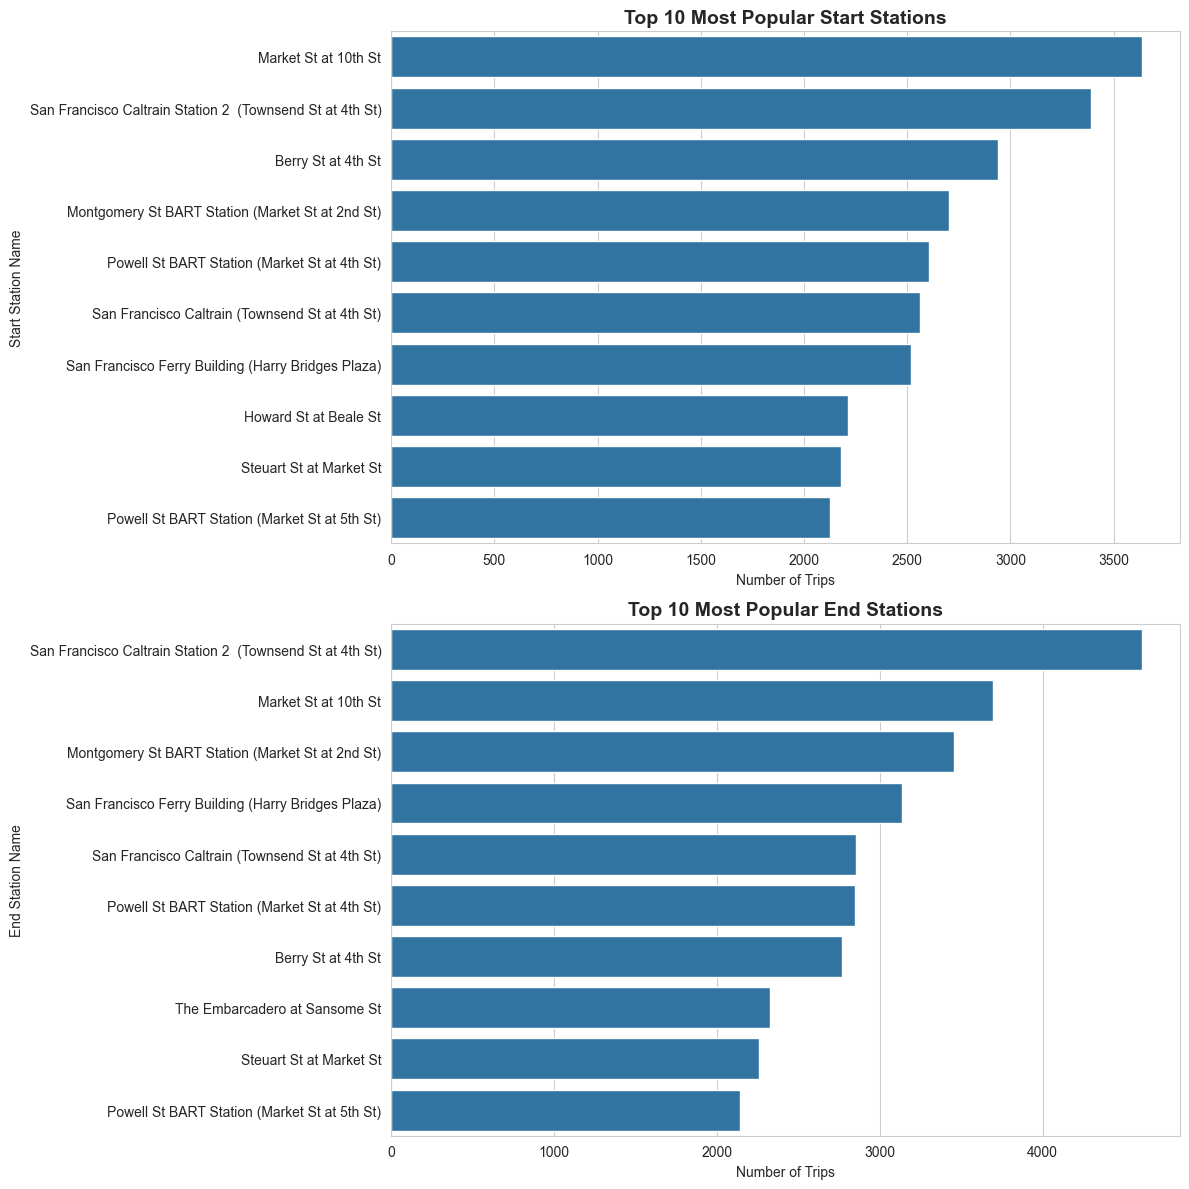

In [20]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 12))

# 1. Top 10 Start Stations
sns.countplot(data=df_top_start, y='start_station_name', color=base_color, 
              order=df_top_start['start_station_name'].value_counts().index, ax=ax[0])
ax[0].set_title('Top 10 Most Popular Start Stations', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Number of Trips')
ax[0].set_ylabel('Start Station Name')

# 2. Top 10 End Stations
sns.countplot(data=df_top_end, y='end_station_name', color=base_color, 
              order=df_top_end['end_station_name'].value_counts().index, ax=ax[1])
ax[1].set_title('Top 10 Most Popular End Stations', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Number of Trips')
ax[1].set_ylabel('End Station Name')

plt.tight_layout()
plt.show()

##  Phase 4.2: Bivariate Analysis
In this section, we will explore the relationships between two different variables to uncover deeper insights. 
**Main questions to answer:**
- Does trip duration depend on the user type (Subscriber vs. Customer)?
- What is the relationship between user type and member gender?
- How does the age of the rider affect the trip duration?

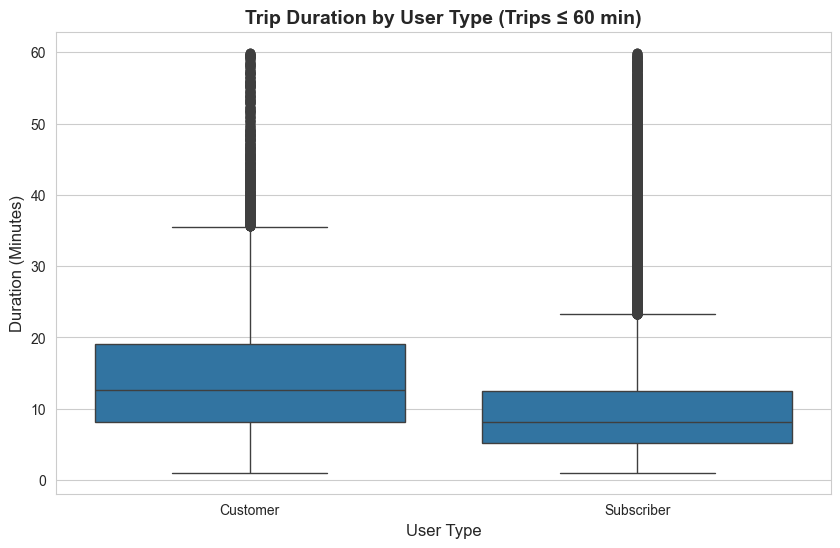

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
base_color = sns.color_palette()[0]

# Boxplot: User Type vs. Trip Duration
# We limit duration to <= 60 minutes for a clearer view of the distribution
sns.boxplot(data=data[data['duration_min'] <= 60], x='user_type', y='duration_min', color=base_color)

plt.title('Trip Duration by User Type (Trips ≤ 60 min)', fontsize=14, fontweight='bold')
plt.xlabel('User Type', fontsize=12)
plt.ylabel('Duration (Minutes)', fontsize=12)
plt.show()

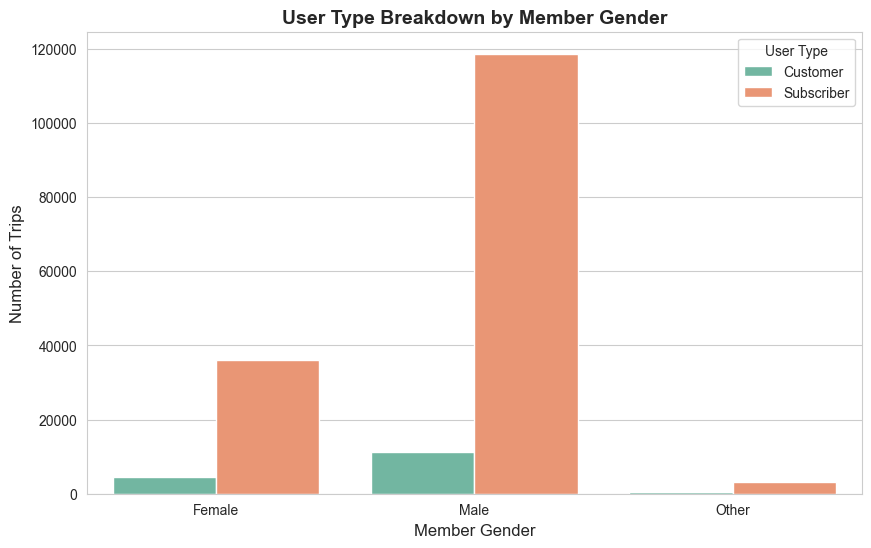

In [22]:
plt.figure(figsize=(10, 6))

# Clustered Bar Chart using 'hue'
sns.countplot(data=data, x='member_gender', hue='user_type', palette='Set2')

plt.title('User Type Breakdown by Member Gender', fontsize=14, fontweight='bold')
plt.xlabel('Member Gender', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.legend(title='User Type')
plt.show()

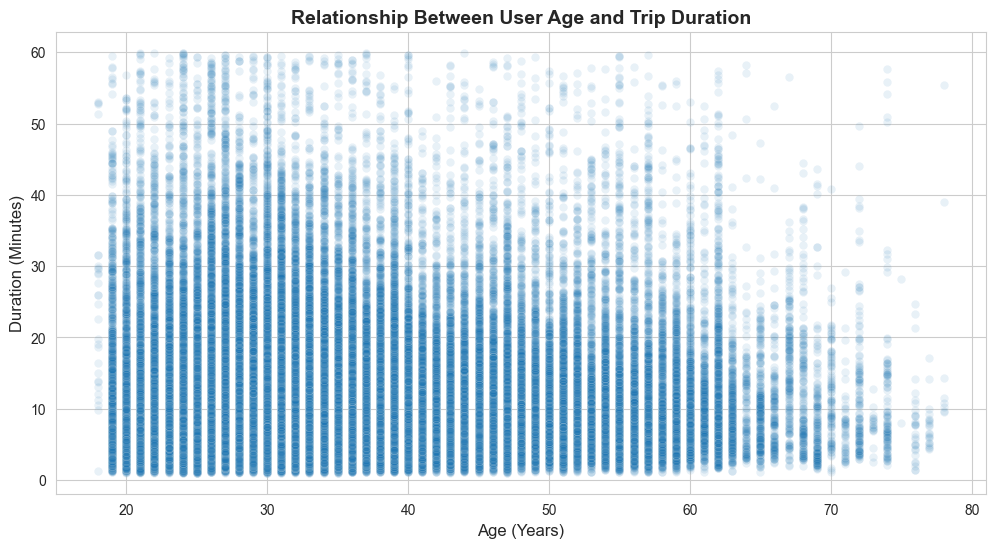

In [23]:
plt.figure(figsize=(12, 6))

# Scatter plot with transparency (alpha) to handle overplotting
sns.scatterplot(data=data[data['duration_min'] <= 60], x='age', y='duration_min', alpha=0.1, color=base_color)

plt.title('Relationship Between User Age and Trip Duration', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Duration (Minutes)', fontsize=12)
plt.show()

##  Phase 4.3: Multivariate Analysis
In this final EDA section, we will explore the interactions between three or more variables simultaneously. This helps us uncover complex patterns that a simple bivariate analysis might miss.
**Main questions to answer:**
- How does the relationship between `age` and `trip duration` change when we factor in the `user_type`?
- How does the average `trip duration` vary across different `genders` and `user types`?

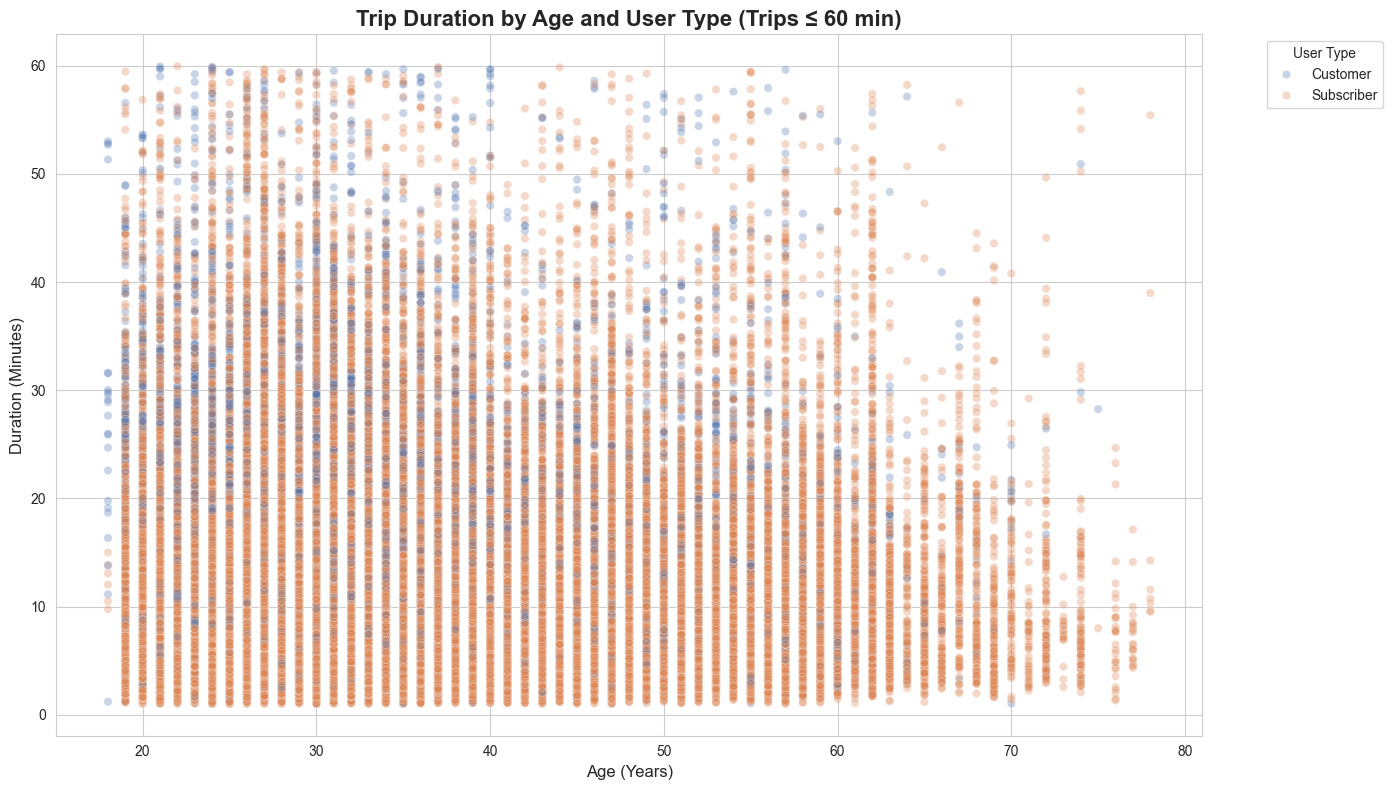

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# Scatter plot: Age vs. Duration, colored by User Type
# Adding hue='user_type' adds the 3rd dimension to our 2D plot
sns.scatterplot(
    data=data[data['duration_min'] <= 60], 
    x='age', 
    y='duration_min', 
    hue='user_type', 
    alpha=0.3,  # Transparency
    palette=['#4C72B0', '#DD8452'] # Custom colors for Subscriber/Customer
)

plt.title('Trip Duration by Age and User Type (Trips ≤ 60 min)', fontsize=16, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Duration (Minutes)', fontsize=12)
plt.legend(title='User Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside

plt.tight_layout()
plt.show()

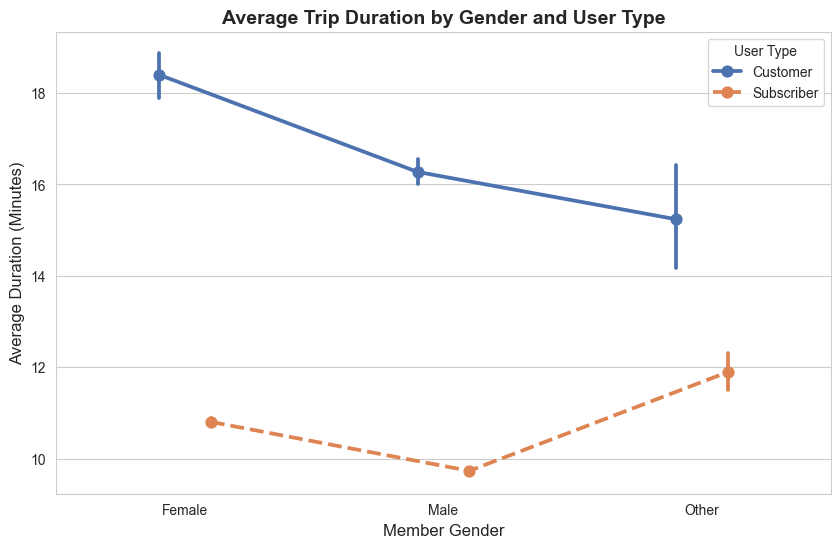

In [25]:
plt.figure(figsize=(10, 6))

# Point plot: Average Duration by Gender and User Type
sns.pointplot(
    data=data, 
    x='member_gender', 
    y='duration_min', 
    hue='user_type',
    palette=['#4C72B0', '#DD8452'],
    linestyles=["-", "--"], # Different line styles for better readability
    dodge=0.2 # Slight offset so points don't overlap
)

plt.title('Average Trip Duration by Gender and User Type', fontsize=14, fontweight='bold')
plt.xlabel('Member Gender', fontsize=12)
plt.ylabel('Average Duration (Minutes)', fontsize=12)
plt.legend(title='User Type')

plt.show()

##  Phase 5: Key Insights & Business Recommendations
Based on the Exploratory Data Analysis (EDA) of the Ford GoBike dataset, we have uncovered several behavioral patterns among riders. Below are the key findings and actionable business recommendations:

###  Key Insights:
1. **The Commuter vs. The Explorer:** - `Subscribers` represent the vast majority of users. They typically take very short, efficient trips (under 15 minutes), acting as daily commuters.
   - `Customers` (casual riders) take significantly longer trips, suggesting they use the bikes for leisure, tourism, or exploratory weekend rides.
2. **Demographic Dominance:** The user base is heavily skewed towards Males aged 25 to 40. Female ridership is noticeably lower but tends to have a slightly higher average trip duration.
3. **Station Popularity:** A small cluster of stations (e.g., Market St, San Francisco Caltrain Station) handles a massive volume of the total traffic, indicating critical transit hubs.

###  Business Recommendations:
1. **Optimize Fleet Rebalancing:** Ensure maximum bike availability at the Top 10 Start/End stations during peak commuting hours to satisfy the massive demand from `Subscribers`. Prevent empty docks at start stations and full docks at end stations.
   
2. **Convert Customers to Subscribers:**
   Since `Customers` spend more time on bikes per trip, introduce a **"Weekend Pass"** or a **"Tourist Subscription"** to capture more value from this segment and encourage them to transition into a recurring revenue model.

3. **Targeted Marketing for Underrepresented Segments:**
   Launch targeted marketing campaigns and safety awareness programs aimed at females and older age groups to close the demographic gap and expand the user base.

4. **Corporate Partnerships:**
   Given the high concentration of users in the 25-40 age bracket (young professionals), Ford GoBike should aggressively pursue corporate partnerships with offices near the most popular transit hubs to offer discounted employee bulk subscriptions.